In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.data.data_cleaning import load_config, project_path
from src.visualization.visualize import (
    plot_numeric_distributions,
    plot_target_balance,
    plot_categorical_vs_target,
    plot_correlation_heatmap,
)

config = load_config("config/config.yaml")
df = pd.read_csv(project_path(config["data"]["interim_path"]))
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          500 non-null    int64  
 1   hours_studied       500 non-null    float64
 2   attendance_rate     500 non-null    float64
 3   sleep_hours         500 non-null    float64
 4   previous_score      500 non-null    float64
 5   parental_education  500 non-null    object 
 6   extracurricular     500 non-null    object 
 7   gender              500 non-null    object 
 8   passed              500 non-null    int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 35.3+ KB


,student_id,hours_studied,attendance_rate,sleep_hours,previous_score,parental_education,extracurricular,gender,passed
0,1273,7.3,87.6,5.1,55.7,High School,No,Male,0
1,1031,3.8,87.7,6.2,67.1,Bachelor,Yes,Female,1
2,1367,5.4,83.4,6.5,80.5,High School,No,Female,1
3,1264,3.0,78.8,5.3,41.0,Bachelor,No,Male,1
4,1163,7.3,79.6,4.7,33.2,Master,Yes,Male,0


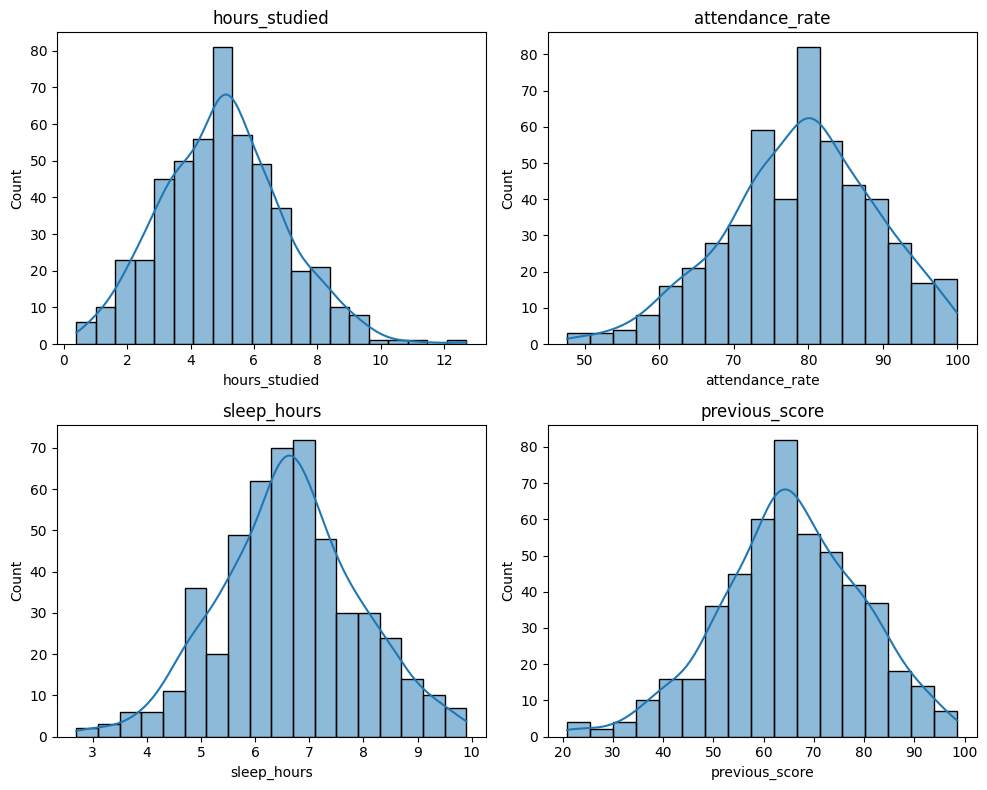

In [2]:
numeric_cols = ["hours_studied", "attendance_rate", "sleep_hours", "previous_score"]
plot_numeric_distributions(df, numeric_cols, config["output"]["figures_path"])

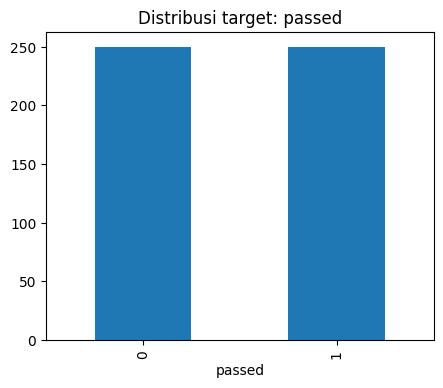

passed
0    0.5
1    0.5
Name: proportion, dtype: float64

In [3]:
plot_target_balance(df, config["data"]["target"], config["output"]["figures_path"])
df[config["data"]["target"]].value_counts(normalize=True)

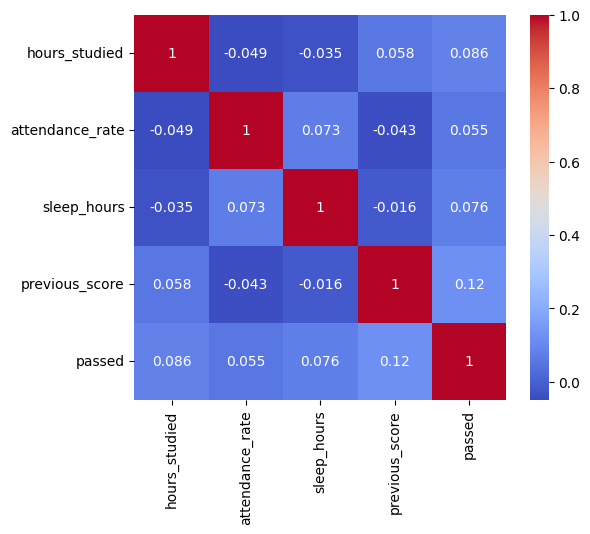

In [4]:
plot_correlation_heatmap(df, numeric_cols, config["data"]["target"], config["output"]["figures_path"])

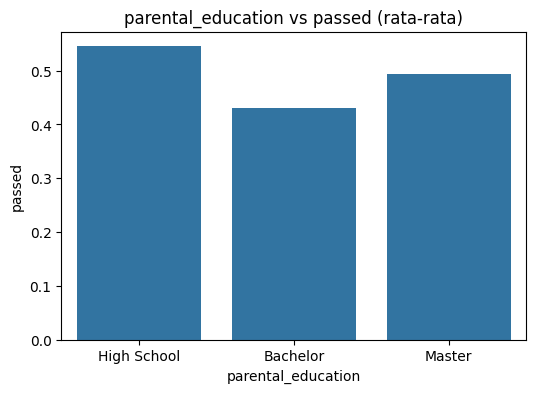

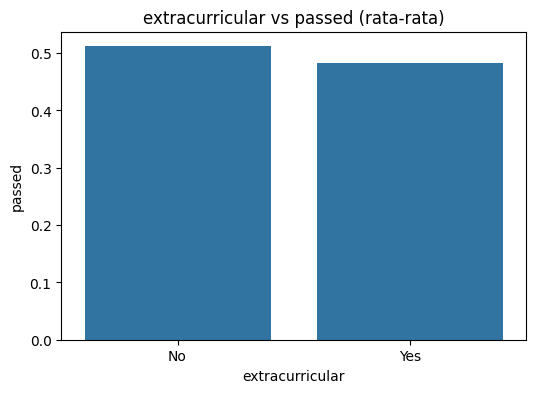

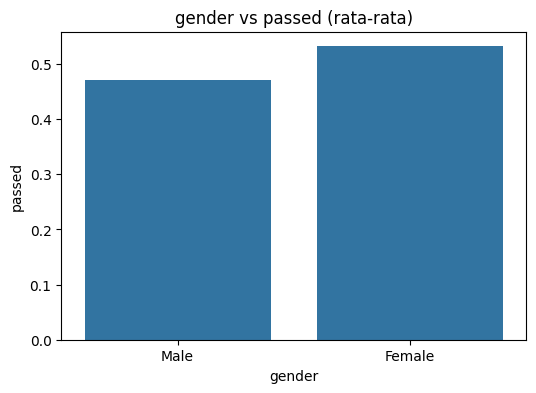

In [5]:
plot_categorical_vs_target(df, "parental_education", config["data"]["target"], config["output"]["figures_path"])
plot_categorical_vs_target(df, "extracurricular", config["data"]["target"], config["output"]["figures_path"])
plot_categorical_vs_target(df, "gender", config["data"]["target"], config["output"]["figures_path"])